![Banner](../assets/banner.png)

## Table of Contents

<div style="font-size: 1.15em; line-height: 1.6;">

</div>



---
---

In [1]:
%matplotlib widget

# std lib imports

# 3-party import
import matplotlib.pyplot as plt
import numpy as np

# projekt imports


---
---

## 1. Introduction


The goal of this notebook is to demonstrate how `sciflow` handles biological high-dimensional data.






---
---

## 2. What is Scifate?


---
---

## 3. Loading the Data

In the following section, the different data structures used for handling and organizing the dataset are introduced.

--- 

### Data Structures

The package is built around three core data structures:

##### `ScifateDataset`

The `ScifateDataset` extends the generic `Dataset` class and represents a dataset specifically tailored to the SciFate format.

It combines:
- the expression matrix
- optional NTR/RNA dynamics information
- cell metadata
- gene metadata
- trajectory information

The dataset internally uses `LabeledSparseMatrix` objects to store both expression and NTR matrices together with 
their corresponding annotations. This provides a convenient interface for working with biological high-dimensional 
data while keeping sparse operations memory efficient.


##### `ScifateLoader`



it dose:
- locating the required dataset files  
- reading them from disk  
- ensuring consistent dimensions  
- transforming all matrices into a unified format  
- constructing a structured `ScifateDataset` object  

In [2]:
from sciflow.data.scifate_dataset import ScifateDataLoader

In [3]:
scifate_loader = ScifateDataLoader()

**Option 1 — Load from folder**

In [4]:
scifate_data = scifate_loader.load(folder_path="/home/nicolas/code/master/higdim/HighDim/data/ScifateData")

**Option 2 — Load from individual files**

In [5]:
scifate_data_ = scifate_loader.load(
    expression_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/matrix.mtx",
    ntr_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/4sU.Binom.ntr.mtx",
    barcodes_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/barcodes.tsv",
    features_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/features.tsv",
    trajectories_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/trajectories_sci.csv",
)

Avter we loaded the dataset we can look at the summary to see that everything worked fine.

In [6]:
print(scifate_data.summary())

ScifateDataset(
  name = SciFateDataset,
  shape = 7404 cells x 43750 genes,
  ntr = yes,
  cell_info = yes,
  gene_info = yes
  trajectory = yes
)


---
---

## 4. Working with the Dataset

After loading the dataset, the expression matrix, NTR matrix, and metadata can be accessed directly. The expression_matrix and the ntr_matrix are `LabeledSparseMatrix` objects.
The Gene Info and the Cell Info will be `pandas.Dataframes` that contain multible features that represent infos about the rows and columns of the NTR matrix and expression Matrix.




---

### 4.1 Inspecting the data within the dataset 

In [7]:
# let's look at the gene info (info about the columns of the ntr and expression matrix)
scifate_data.gene_info.head(3)

,gene_id,gene_name,feature_type,region,length
0,ENSG00000225602,MTOR-AS1,Gene Expression,Exonic (h.ens90),705
1,ENSG00000171819,ANGPTL7,Gene Expression,Exonic (h.ens90),2238
2,ENSG00000238173,RPL39P6,Gene Expression,Exonic (h.ens90),150


In [8]:
# let's look at the cell info (info about the rows of the ntr and expression matrix)
scifate_data.cell_info.head(3)

,barcode,cell_line,time,cell_barcode
0,A549.4h.AAAAACTCTCTCAA,A549,4h,AAAAACTCTCTCAA
1,A549.6h.AAAAAAGAAGTTCA,A549,6h,AAAAAAGAAGTTCA
2,A549.8h.AAAAACGGAGAATA,A549,8h,AAAAACGGAGAATA


We can also look and work with the expression_matrix and the NTR matrix in a sparse form and also in a rendered full matrix form.

In [9]:
print(scifate_data.expression_matrix.matrix_sparse[30:60, 30:60])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (30, 30)>
  Coords	Values
  (1, 26)	1
  (4, 7)	1
  (25, 20)	1


In [10]:
print(scifate_data.expression_matrix.head(n = 3))

                        MTOR-AS1  ANGPTL7  RPL39P6
A549.4h.AAAAACTCTCTCAA         0        0        0
A549.6h.AAAAAAGAAGTTCA         0        0        0
A549.8h.AAAAACGGAGAATA         0        0        0


In [11]:
print(scifate_data.expression_matrix.summary())

LabeledSparseMatrix(
  name=expression_matrix,
  shape=(7404, 43750),
  dtype=int64,
  not_zero=43838929,
  density=13.5337%,
  is_view=True,
  row_info=['barcode', 'cell_line', 'time', 'cell_barcode'],
  col_info=['gene_id', 'gene_name', 'feature_type', 'region', 'length']
)


---
### Working with the data within the dataset 
Because both expression_matrix and ntr_matrix are `LabeledSparseMatrix` objects we can select data by rows and columns to get a new view on the sparse matrix with that we can work.

In [12]:
expression_matrix = scifate_data.expression_matrix

print(f"Type of expression_matrix: {type(expression_matrix)}")

# selecting diverent properties from the expression matrix
expression_4h = expression_matrix.select_rows(time="4h")

print(f"Type of expression_4h: {type(expression_4h)}")

print()
print(f"Expression Matrix 4h {expression_4h.shape} head:")
print(expression_4h.head(5))

Type of expression_matrix: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>
Type of expression_4h: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>

Expression Matrix 4h (1045, 43750) head:
                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


Because we get a "new" `LabeledSparseMatrix` from the select we can select even further or chain selection operations.

In [13]:
expression_4h_cells = expression_matrix.select_rows(cell_barcode=["AAAAACTCTCTCAA", "AAAACGATCCTGGA", "AAAAATAAGAGGCG"]).select_cols(gene_id=["ENSG00000225602", "ENSG00000171819", "ENSG00000238173"])

print(expression_4h_cells)

                        MTOR-AS1  ANGPTL7  RPL39P6
A549.4h.AAAAACTCTCTCAA         0        0        0
A549.4h.AAAACGATCCTGGA         0        0        0
A549.4h.AAAAATAAGAGGCG         0        0        0


Now we have three diverent `LabeledSparseMatrix` but we dont save the matrix and the infos in all of them the selected ones will just be a view of the original  `LabeledSparseMatrix` 

In [14]:
print(f"Same object:                {id(expression_matrix) == id(expression_4h) == id(expression_4h_cells)}")
print("-" * 35)
print(f"Shared matrix object:       {id(expression_matrix._matrix) == id(expression_4h._matrix) == id(expression_4h_cells._matrix)}")
print(f"Shared row_info object:     {id(expression_matrix._row_info) == id(expression_4h._row_info) == id(expression_4h_cells._row_info)}")
print(f"Shared col_info object:     {id(expression_matrix._col_info) == id(expression_4h._col_info) == id(expression_4h_cells._col_info)}")

Same object:                False
-----------------------------------
Shared matrix object:       True
Shared row_info object:     True
Shared col_info object:     True


---
#### Numpy-like indexing

The `LabeledSparseMatrix` also suports NumPy-like indexing. The returned object is again a `LabeledSparseMatrix`, allowing chained selections and preserving all metadata.

In [15]:
# Select a single element
expression_matrix_entery = scifate_data.expression_matrix[100,100]

print(expression_matrix_entery)

                        TUBB8P11
A549.0h.CTACCCTGCATCAA         0


In [16]:
# Select a single row
expression_matrix_column = scifate_data.expression_matrix[100,:].head(5)

print(expression_matrix_column)

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.0h.CTACCCTGCATCAA         0        0        0         0        0


In [17]:
# Select a single column
expression_matrix_column = scifate_data.expression_matrix[:,10].head(7)

print(expression_matrix_column)

                         PRAMEF12
A549.4h.AAAAACTCTCTCAA          0
A549.6h.AAAAAAGAAGTTCA          0
A549.8h.AAAAACGGAGAATA          0
A549.4h.AAAACGATCCTGGA          0
A549.6h.AAAAACTGAATTCC          0
A549.2h.AAAAGCCATCAACT          0
A549.10h.AAAATTGAGTATCA         0


In [18]:
# Select with a bolen mask 
mask = (scifate_data.expression_matrix.row_info["time"] == "4h")
expression_matrix_4h = scifate_data.expression_matrix[mask, :]

print(expression_matrix_4h.head(5))

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


--- 

#### Working with trajectories

Besides the expression and NTR matrices, the dataset also contains trajectory information describing temporal relationships between cells across different time points.
These trajectories can be used to directly extract and analyze dynamic expression patterns over time.

In [19]:
print(f"Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: {scifate_data.get_trajectory_id(barcode="A549.6h.GCGAGGCCTCCATT")}")

Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: 5


In [20]:
scifate_data.get_trajectory_expression(trajectory_id=5).head(5)

,MTOR-AS1,ANGPTL7,RPL39P6,SNORA59A,AADACL4
A549.8h.AAACAACTACCGAC,0,0,0,0,0
A549.10h.ACCTGGTCCAGGAG,0,0,0,0,0
A549.0h.CTGTAGGTCTATGG,0,0,0,0,0
A549.6h.GCGAGGCCTCCATT,0,0,0,0,0
A549.4h.GCGGATCCTACCTC,0,0,0,0,0


In [21]:
scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC").head(5)

,MTOR-AS1,ANGPTL7,RPL39P6,SNORA59A,AADACL4
A549.8h.AAACAACTACCGAC,0,0,0,0,0
A549.10h.ACCTGGTCCAGGAG,0,0,0,0,0
A549.0h.CTGTAGGTCTATGG,0,0,0,0,0
A549.6h.GCGAGGCCTCCATT,0,0,0,0,0
A549.4h.GCGGATCCTACCTC,0,0,0,0,0


--- 

#### Working with new RNA


In [22]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

new_rna = expression_cells * ntr_cells                                                                              # calculating the new_rna per time step for the 5 cells

new_rna[:, 190:195]                                                                                                

                         FAM76A  AL161638.1  MATN1-AS1  LINC01778   PNRC2
A549.8h.AAACAACTACCGAC      0.0         0.0        0.0        0.0  0.0000
A549.10h.ACCTGGTCCAGGAG     0.0         0.0        0.0        0.0  0.0000
A549.0h.CTGTAGGTCTATGG      0.0         0.0        0.0        0.0  0.0000
A549.6h.GCGAGGCCTCCATT      1.0         0.0        0.0        0.0  0.0000
A549.4h.GCGGATCCTACCTC      0.0         0.0        0.0        0.0  1.0000
A549.2h.ATCTATCTAGGTTC      0.0         0.0        0.0        0.0  2.0805

--- 

#### Working with old RNA


In [23]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

old_rna = expression_cells - (expression_cells * ntr_cells)                                                         # calculating the new_rna per time step for the 5 cells

print(old_rna[ : , 190 : 195])                                                                                      # print cols where something is :D

                         FAM76A  AL161638.1  MATN1-AS1  LINC01778   PNRC2
A549.8h.AAACAACTACCGAC      0.0         0.0        0.0        0.0  0.0000
A549.10h.ACCTGGTCCAGGAG     0.0         0.0        0.0        0.0  0.0000
A549.0h.CTGTAGGTCTATGG      0.0         0.0        0.0        0.0  0.0000
A549.6h.GCGAGGCCTCCATT      0.0         0.0        0.0        0.0  0.0000
A549.4h.GCGGATCCTACCTC      0.0         0.0        0.0        0.0  0.0000
A549.2h.ATCTATCTAGGTTC      1.0         0.0        0.0        0.0  0.9195


---
---

### Exploratory Data Analysis

---

### Highly Variable Genes

In the previous section, we investigated transcriptional heterogeneity from the perspective of cells and identified cells that occupy isolated positions in expression space.
A natural next question is which genes are responsible for these differences.
Not all genes contribute equally to cellular heterogeneity. Many genes are expressed at similar levels across nearly all cells and therefore provide little information for distinguishing cellular states. Other genes show substantial variation between cells and often drive the separation of cell populations.
To identify such informative genes, we calculate variability scores for every gene and rank them according to their expression variability across all cells.
Genes with the highest variability are commonly referred to as Highly Variable Genes (HVGs) and play a central role in many downstream single-cell analyses, including dimensionality reduction, clustering, trajectory inference, and cell type identification.

In [24]:
gene_scores = scifate_data.create_gene_variability_scores(
    data="expression",
    sort_by="variance"
)

gene_scores.head(5)

,gene_id,gene_name,feature_type,region,length,mean_expression,variance
0,ENSG00000210082,MT-RNR2,Gene Expression,Exonic (Mito),1559,3603.659373,2.920986e+06
1,ENSG00000211459,MT-RNR1,Gene Expression,Exonic (Mito),954,1081.393436,3.231179e+05
2,ENSG00000198886,MT-ND4,Gene Expression,Exonic (Mito),1378,360.509589,3.072215e+04
3,ENSG00000251562,MALAT1,Gene Expression,Exonic (h.ens90),8708,122.123177,1.734350e+04
4,ENSG00000205426,KRT81,Gene Expression,Exonic (h.ens90),1929,159.832388,1.203472e+04


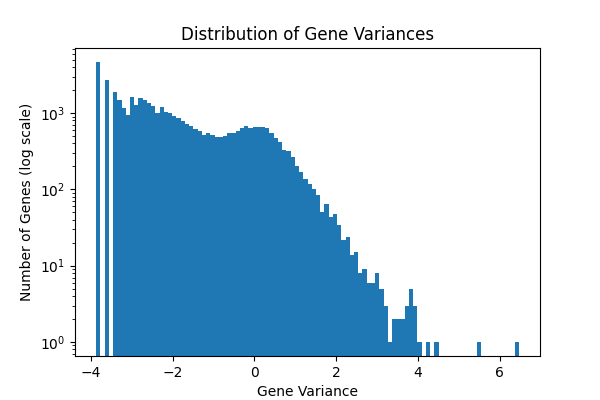

In [25]:
fig, ax = plt.subplots(figsize=(6,4))

plt.hist(
    np.log10(gene_scores["variance"] + 1e-8),
    bins=100
)

plt.xlabel("log10(Variance)")
plt.ylabel("Number of Genes")

ax.set_yscale("log")

ax.set_title("Distribution of Gene Variances")
ax.set_xlabel("Gene Variance")
ax.set_ylabel("Number of Genes (log scale)")

plt.show()

The variance distribution is strongly skewed, with most genes exhibiting only limited variability across cells and a relatively small number of genes showing substantially larger variances.

This observation is expected in single-cell datasets. While many genes correspond to housekeeping functions and remain relatively stable across cells, a smaller subset of genes captures biologically meaningful differences between cellular states. These highly variable genes contain a large fraction of the information required to distinguish cell populations and are therefore commonly selected for downstream analyses.

---
---
## 4. Distances and Heatmaps on parts of the data

---

### Distance Metrics

Different biological questions often require different notions of similarity. The package therefore provides multiple interchangeable distance metrics built on top of a shared `BaseDistance` interface.

--- 
#### The distances used in the notbook are:

##### <span style="color:lightgreen">1. Cosine Distance</span>
Instead of comparing absolute magnitudes, it compares the **direction** of two expression vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{cos}}(x, y)=1 -\frac{x^\top y}{\|x\|\|y\|}$


##### <span style="color:lightgreen">2. Correlation Distance</span>
Correlation distance compares the **relative variation structure** between vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{corr}}(x, y) = 1 - \frac{(x - \bar{x})^\top (y - \bar{y})}{\|x - \bar{x}\| \, \|y - \bar{y}\|}$

Instead of absolute expression values, it focuses on up/down regulation patterns and the relative feature behavior.
Because centering destroys sparsity, correlation distance internally operates on dense representations.


##### <span style="color:lightgreen">3. Manhattan Distance</span>
Manhattan distance measures the absolute element-wise differences between two vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{man}}(x, y)=\sum_i |x_i-y_i|$

Instead of considering vector direction or correlation structure, Manhattan distance directly accumulates the absolute differences across all features.
This makes it sensitive to magnitude changes while often being more robust to outliers than Euclidean distance.
In the context of gene expression data, Manhattan distance reflects the total absolute transcriptional difference between two cells or genes across all measured features.

---

In [26]:
from sciflow.distance import CorrelationDistance, CosineDistance, ManhattanDistance, EuclideanDistance

---
### Calculating and Visualizing the Distance Matrices



Internally, the rows are always interpreted as data points and the columns as features. 

For example:

- cell distances:
  rows = cells, columns = genes

- gene distances:
  rows = genes, columns = cells

- trajectory distances:
  rows = trajectories, columns = concatenated trajectory features

The resulting distance matrices are stored as `LabeledDistanceMatrix` objects and can optionally be cached inside the dataset for later reuse.

In [27]:
from sciflow.plotting.scifate_plotter import ScifatePlotter

plotter = ScifatePlotter(dataset=scifate_data)

---
##### <span style="color:lightblue">1. Distance Matrix of Cells Along a Single Trajectory</span>


One of the first ways to analyze and better understand the scifate data is to investigate the similarity between different cells. Instead of directly analyzing thousands of individual genes, we can compare entire gene expression profiles between cells and quantify how similar or dissimilar they are to each other. This allows us to identify whether cells share similar transcriptional states, belong to related biological conditions, or follow common developmental processes. To achieve this, pairwise distances between cells can be computed based on their gene expression profiles. The resulting distance matrix provides a compact representation of the relationships between all cells in the dataset and forms the basis for further analyses such as clustering, trajectory validation, and visualization of temporal progression.

In [28]:
# Calculate the distance betweean diverent cells from the same trajectory
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                                 # This will give us 5 Cells with each 40k genes

cells_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_cells, distance=CorrelationDistance(), entity="cell", data="expression", save=True)

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 132.53it/s]


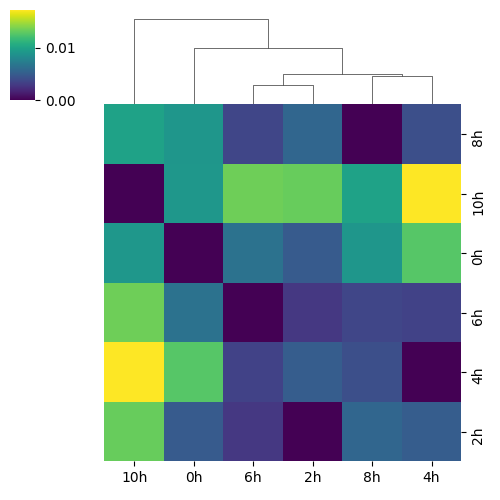

In [29]:
cells_dist_matrix.row_label, cells_dist_matrix.col_label = "time", "time"   

fig =  plotter.plot_distance_matrix(dist_matrix=cells_dist_matrix, cluster_rows=False, cluster_cols=True, figsize=(5,5))

The hierarchical clustering reorganizes the rows and columns such that transcriptionally similar cells are placed next to each other.  
The dendrogram therefore visualizes the similarity structure of the trajectory and reveals which time points cluster together based on their global gene expression behavior.

In this example, neighboring time points tend to show smaller distances, indicating a gradual temporal progression of the cellular state along the trajectory.

---
##### <span style="color:lightblue">2. Distance Matrix of Different Genes</span>

Besides comparing cells, it is also possible to investigate the similarity between genes themselves. Instead of treating cells as observations, the expression profiles of genes across multiple cells are compared to identify genes that exhibit similar transcriptional behavior. Genes with small distances show similar expression patterns across the analyzed cells, which may indicate shared biological functions, co-regulation, or participation in common cellular pathways. In contrast, genes with larger distances behave more independently and may be associated with different biological processes. By computing pairwise distances between genes, the resulting distance matrix captures the global relationship structure between all analyzed genes. Such matrices are useful for identifying groups of co-expressed genes, exploring transcriptional programs, and detecting potential functional relationships between genes.

In [30]:
# Calculate the distance betweean diverent genes
expression_genes = scifate_data.expression_matrix[:, [10,20,30,40,50,60]].T                                                                 # here we need to transpose the matrix because we always    
genes_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_genes, distance=ManhattanDistance())

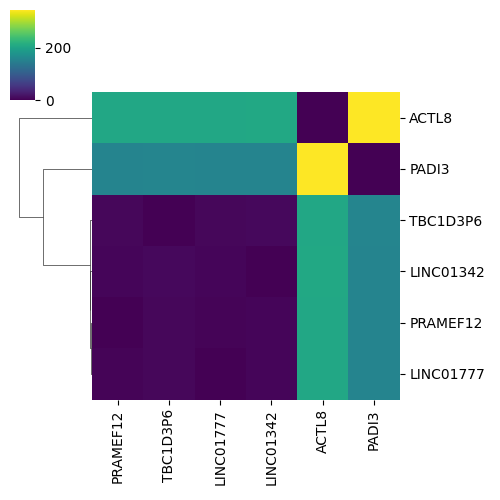

In [31]:
fig = plotter.plot_distance_matrix(dist_matrix=genes_dist_matrix, cluster_rows=True, figsize=(5,5))

---
##### <span style="color:lightblue">3. Distance Matrix of Different Trajectories</span>

Beyond comparing individual cells or genes, entire trajectories can also be compared with each other. In this setting, each trajectory represents a temporal sequence of cellular states, and the distance matrix measures how similar or dissimilar these overall developmental patterns are. Trajectories with small distances exhibit similar transcriptional dynamics over time, suggesting that they may follow related biological processes or cellular responses. Larger distances indicate stronger differences in temporal gene expression behavior and may point to distinct biological pathways or developmental programs. To compute trajectory-level distances, the expression information of all cells belonging to a trajectory is aggregated into a trajectory representation vector. Pairwise distances between these vectors then provide a compact summary of the relationships between complete trajectories. The resulting distance matrix enables the identification of groups of trajectories with similar temporal behavior and helps to reveal higher-level structures within the dataset.

In [32]:
# Calculate the distance berwean diveren trajectorys 
trajectory_dist_matrix = scifate_data.create_distance_matrix(entity="trajectory", data="expression", distance=CosineDistance())[:20, :20]

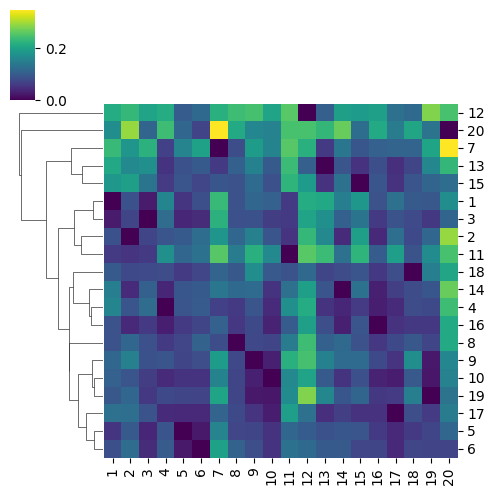

In [33]:
fig =  plotter.plot_distance_matrix(dist_matrix=trajectory_dist_matrix, cluster_cols=False, cluster_rows=True, figsize=(5,5))

---
##### <span style="color:lightblue">4. Distance Matrix of Cells New RNA</span>

Besides analyzing total gene expression, it is also possible to specifically investigate the similarity between cells based only on newly transcribed RNA. Instead of using the complete expression profiles, the expression counts are weighted by the NTR (new-to-total RNA ratio), resulting in an approximation of the newly synthesized RNA for each gene and cell. This representation focuses on active and recent transcriptional activity rather than accumulated total RNA abundance. As a result, the corresponding distance matrix captures similarities in ongoing gene regulation and dynamic cellular responses. Cells with small distances therefore exhibit similar patterns of newly produced RNA, suggesting comparable current transcriptional programs or biological activity. Larger distances indicate stronger differences in active transcriptional behavior between cells. The clustered distance matrix can help reveal dynamic transcriptional transitions that may not be as visible in the total expression matrix alone.

In [34]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

new_rna = expression_cells * ntr_cells                                                                              # calculating the new_rna per time step for the 5 cells

new_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=new_rna, 
                                                            distance=CorrelationDistance()
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 454.62it/s]


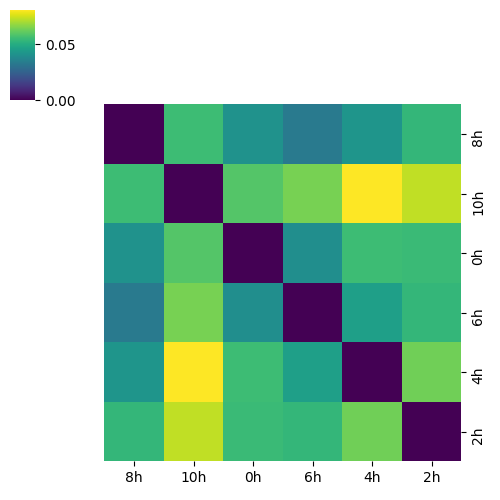

In [35]:
new_rna_dist_matrix.row_label, new_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=new_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

---
##### <span style="color:lightblue">5. Distance Matrix of Cells Old RNA</span>

In addition to newly synthesized RNA, similarities between cells can also be analyzed based on old RNA. Here, the newly transcribed fraction is subtracted from the total expression profile, resulting in an approximation of the remaining pre-existing RNA within each cell. While new RNA mainly reflects recent transcriptional activity, old RNA captures the more stable and accumulated transcriptional state of the cell. The corresponding distance matrix therefore emphasizes longer-term expression patterns rather than immediate transcriptional changes. Cells with small distances exhibit similar old RNA compositions, indicating comparable persistent cellular states or previously established transcriptional programs. Larger distances suggest stronger differences in the underlying accumulated RNA landscape between cells. Comparing the old RNA distance matrix with the new RNA distance matrix can provide additional biological insight into which similarities arise from stable cellular identity and which are driven by ongoing dynamic transcriptional processes.

In [36]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

old_rna = expression_cells - (expression_cells * ntr_cells)                                                         # calculating the old_rna per time step for the 5 cells

old_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=old_rna, 
                                                            distance=CorrelationDistance(), 
                                                            entity="cell", 
                                                            data="expression", 
                                                            save=True
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 477.71it/s]


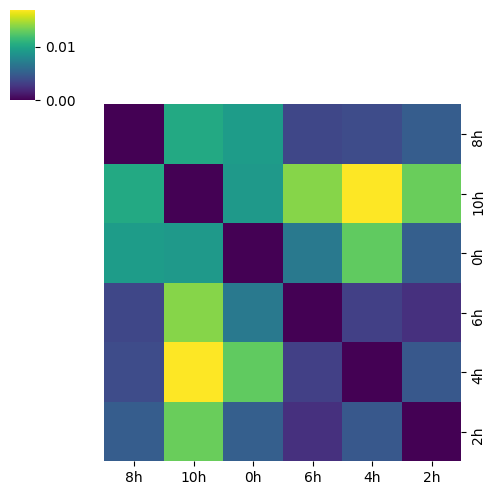

In [37]:
old_rna_dist_matrix.row_label, old_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=old_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

---
---
## 5. Distance Matrix on the Whole Dataset

For large single-cell datasets, computing distances between all cells or genes can become expensive very quickly. The reason is that a pairwise distance matrix compares every cell with every other cell. For $n$ cells, this means we need to compute $\frac{n(n-1)}{2}$ unique pairwise distances. In other words, the number of computations grows quadratically with the number of cells. This is still manageable for small datasets, but for larger datasets it can become a major bottleneck. If we want to compute all cell wise distances we would have:


In [38]:
print("For the cell Distance Matrix we have:")
print(f"Total cells: {scifate_data.expression_matrix.n_rows}")
print(f"Total computations: {scifate_data.expression_matrix.n_rows * (scifate_data.expression_matrix.n_rows - 1) // 2:,}")

print()
print("For the gene Distance Matrix we have:")
print(f"Total genes: {scifate_data.expression_matrix.n_cols}")
print(f"Total computations: {scifate_data.expression_matrix.n_cols * (scifate_data.expression_matrix.n_cols - 1) // 2:,}")

For the cell Distance Matrix we have:
Total cells: 7404
Total computations: 27,405,906

For the gene Distance Matrix we have:
Total genes: 43750
Total computations: 957,009,375


Even though the number of pairwise comparisons is large, some distance metrics are still practical to compute.
This is especially true for distances that can be efficiently vectorized or are implemented in optimized low-level code, for example in NumPy, SciPy, or scikit-learn. Cosine distance is a good example. Instead of manually looping over every pair of cells in Python, we can use an optimized implementation that computes the full pairwise distance matrix much faster. On my Computer it took around 2 Minutes.

In [39]:
# This will calculate the distance of all cells to each other with the Cosine distance and save it in the scifate dataset

cell_dist_matrix = scifate_data.create_distance_matrix(
                                                            entity="cell",
                                                            data="expression", 
                                                            distance=CosineDistance(),
                                                            save=True
                                                        )

Euclidean distance can also be computed efficiently on sparse expression matrices. Similar to Cosine distance, highly optimized implementations are available in libraries such as SciPy. Therefore, computing the full Euclidean distance matrix is usually feasible even for larger datasets. On my Computer it took around 2 Minutes.

In [40]:
# This will calculate the distance of all cells to each other with the Euclidean Distance and save it in the scifate dataset

# new_rna_dist_matrix = scifate_data.create_distance_matrix(
#                                                             entity="cell",
#                                                             data="expression", 
#                                                             distance=EuclideanDistance(),
#                                                             save=True
#                                                         )

Once a distance matrix has been computed with `save=True`, it is automatically stored inside the `ScifateDataset`. This avoids the need to recompute expensive distance matrices multiple times and allows them to be reused throughout the analysis workflow. Stored distance matrices can be retrieved at any time using the corresponding entity, data source, and distance metric:


In [41]:
# plotter.plot_distance_matrix(
#     entity="cell",
#     data="expression",
#     distance=CosineDistance(),
#     n_samples=30
# )

For the other two distance metrics, Correlation distance and Manhattan distance, computing the full distance matrix is much more expensive. In my case, calculating the full matrix took around 45 minutes.

The main problem with Correlation distance is that it requires centering each row by subtracting the row mean. This destroys the sparsity of the expression matrix. A sparse matrix only stores non-zero values, which makes it memory-efficient. However, after subtracting the mean, many previously zero entries become non-zero. As a result, the matrix effectively becomes dense and requires much more RAM. Because of this, the full Correlation distance matrix cannot be computed efficiently in one step for larger datasets. Instead, the computation has to be done blockwise. This avoids loading the full dense matrix into memory at once, but it makes the computation much slower.

For Manhattan distance, the problem is different. Although it can be computed on sparse data, it is less efficient for this use case because it depends on the absolute difference across all genes for every pair of cells. With many cells and many genes, this leads to a very large number of operations. Therefore, calculating the full Manhattan distance matrix for the complete dataset is also very time-consuming.

---
### Random Projections

To address this, random projections can be used to project the data into a lower-dimensional space while still approximately preserving the distances between cells. Under certain conditions, the projected distances remain close to the original distances of the high-dimensional data. This makes it possible to compute distance matrices more efficiently without completely losing the geometric structure of the dataset.

One important theoretical foundation is the Johnson–Lindenstrauss lemma. It states that a set of n points can be projected into a significantly lower-dimensional space such that pairwise distances are preserved up to a small error. More formally, for an error parameter $\varepsilon \in (0, 1)$, there exists a projection into dimension:

$k = \mathcal{O}\left(\frac{\log n}{\varepsilon^2}\right)$.

such that the distances between all pairs of points are approximately maintained with high probability. This provides the theoretical basis for using random projections in large-scale distance computations. For our dataset and the two aplications of all cell and all gene distances we get.

In [42]:
from sciflow.reduction.random_projection import RandomProjektions, jl_dimension, test_random_projection_matrix

In [43]:
print(f"Cells: {scifate_data.expression_matrix.n_rows:,}")
print(f"Required dimension for cells (eps=0.2): {jl_dimension(scifate_data.expression_matrix.n_rows):,}")

print()

print(f"Genes: {scifate_data.expression_matrix.n_cols:,}")
print(f"Required dimension for genes (eps=0.2): {jl_dimension(scifate_data.expression_matrix.n_cols):,}")

Cells: 7,404
Required dimension for cells (eps=0.2): 2,057

Genes: 43,750
Required dimension for genes (eps=0.2): 2,467


The Johnson–Lindenstrauss bound provides a theoretical guarantee on the projection dimension required to preserve pairwise distances within a specified error tolerance. However, this bound is generally conservative and represents a worst-case scenario. In practice, much lower projection dimensions are often sufficient to preserve the relevant geometric structure of the data.

Therefore, instead of relying solely on the theoretical bound, it is useful to empirically evaluate how well different projection dimensions preserve the original distances. By comparing pairwise distances before and after projection, we can quantify the error introduced by the dimensionality reduction and determine a suitable trade-off between computational efficiency and distance preservation.

In the following experiment, random projections with different target dimensions are applied to the dataset. For each projection dimension, the pairwise distances in the projected space are compared to the original distances, and the resulting error is measured. This allows us to assess how much information is lost when reducing the dimensionality and to identify projection dimensions that provide a good approximation of the original distance structure.

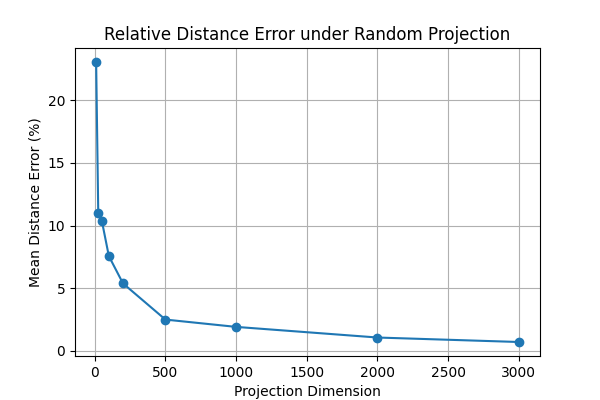

In [44]:
results = test_random_projection_matrix(
    matrix= scifate_data.expression_matrix.matrix,
    dimensions= [10, 25, 50, 100, 200, 500, 1000, 2000, 3000],
    n_samples= 500,
    metric= "euclidean",
    n_repeats= 5
)

plt.figure(figsize=(6, 4))

plt.plot(
    results["projection_dimension"],
    results["mean_percent_error"],
    marker="o"
)

plt.xlabel("Projection Dimension")
plt.ylabel("Mean Distance Error (%)")
plt.title("Relative Distance Error under Random Projection")
plt.grid(True)

plt.show()

The previous experiment showed that random projections can preserve the pairwise distances reasonably well even when the data is projected into a much lower-dimensional space. Therefore, random projections can be used as a preprocessing step before computing a distance matrix on the complete dataset.

Instead of calculating distances in the original high-dimensional expression space, the data is first projected into a lower-dimensional representation. The distance matrix is then computed using the projected data. This can significantly reduce both computation time and memory requirements while still maintaining a good approximation of the original distance structure.

In Sciflow, random projections can be passed directly as a dimensionality reduction step when creating a distance matrix. For example, the full cell-cell Euclidean distance matrix can be computed on a randomly projected representation of the expression matrix as follows:

In [45]:
new_rna_dist_matrix = scifate_data.create_distance_matrix(
    entity="cell",
    data="expression",
    distance=CorrelationDistance(),
    reduction=RandomProjektions(
        data_dim=scifate_data.expression_matrix.n_cols,
        feature_dim=500
    ),
    save=True
)

CorrelationDistance: 100%|██████████| 8/8 [00:05<00:00,  1.48it/s]


In this example, the original gene expression vectors are projected to 100 dimensions before the pairwise Euclidean distances are calculated. Depending on the chosen projection dimension, this can lead to substantial speedups while introducing only a small approximation error in the resulting distance matrix.

Although random projections are used here as an example, the distance matrix framework is not limited to this particular reduction method. Any dimensionality reduction technique that follows the Sciflow reduction interface can be used in the same way. This includes methods such as PCA, autoencoder-based reductions, and other techniques that will be introduced in Section: 
<span style="color:orange">7. Dimension Reduction and Plotting Data</span>. This makes it possible to experiment with different low-dimensional representations while keeping the distance matrix computation workflow unchanged.

---


### Cell Distance Scores

A full cell-to-cell distance matrix contains much more information about the data than a heatmap can show. For each cell, we can summarize how far away it is from all other cells or from its local neighborhood.
This allows us to identify cells that are transcriptionally unusual compared to the rest of the dataset.

Biologically, cells with high distance scores may represent:

* rare cell states
* transitional cells
* potential outliers
* low-quality cells
* cells from a strongly different time point or condition

Instead of visually inspecting the full distance matrix, we compute summary scores for every cell and sort them by their distance to their nearest neighbors.


In [46]:
cell_scores = scifate_data.create_distance_scores(
    entity="cell",
    data="expression",
    distance=CosineDistance(),
    sort_by="mean_distance"
)

cell_scores.head(5)

,barcode,cell_line,time,cell_barcode,trajectory,mean_distance,median_distance,nearest_neighbor_distance
0,A549.8h.CTTGGGTCGCTATG,A549,8h,CTTGGGTCGCTATG,NaN,0.780965,0.789357,0.335661
1,A549.2h.ATGAGAGGTCGGTT,A549,2h,ATGAGAGGTCGGTT,NaN,0.648318,0.659839,0.184918
2,A549.0h.AGTTGGTTGGCGAC,A549,0h,AGTTGGTTGGCGAC,NaN,0.562402,0.572271,0.192627
3,A549.0h.CTCAATAATCTCGC,A549,0h,CTCAATAATCTCGC,NaN,0.450637,0.457922,0.182579
4,A549.8h.CGTGTAGAATAGCC,A549,8h,CGTGTAGAATAGCC,NaN,0.408560,0.415366,0.194138


The resulting table ranks all cells according to their average distance to the remaining cells in the dataset. Cells with large mean distances occupy isolated positions in expression space and therefore exhibit transcriptional profiles that differ substantially from the majority of cells. Such cells may represent rare biological states, transitional phenotypes, or technical outliers.

To better understand the overall distribution of cell heterogeneity within the dataset, we can visualize the distribution of mean cell distances using a histogram. This allows us to identify whether the dataset contains only a few isolated cells or whether transcriptional diversity is broadly distributed across the population.

A long right tail would indicate the presence of highly distinct cells, whereas a narrow distribution would suggest a relatively homogeneous cell population.

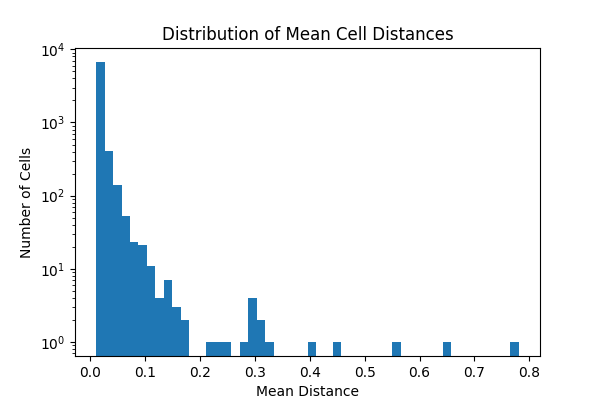

In [47]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    cell_scores["mean_distance"],
    bins=50,
    log=True
)

ax.set_title("Distribution of Mean Cell Distances")
ax.set_xlabel("Mean Distance")
ax.set_ylabel("Number of Cells")

plt.show()

The distribution of mean cell distances is characterized by a long right tail, indicating that transcriptional heterogeneity is not uniformly distributed across the dataset.
While most cells are embedded in dense regions of expression space and exhibit similar transcriptional profiles, a small fraction of cells occupies more distant positions. These cells contribute strongly to the overall variability of the dataset and may represent rare or specialized transcriptional states.

This observation suggests that the population consists primarily of common cellular states accompanied by a smaller number of highly distinct cells.

---
---
## 6. Clustering Methods
One of the main goals of single-cell transcriptomics is the identification of groups of cells that share similar transcriptional profiles.

Rather than analyzing thousands of cells individually, clustering methods partition the dataset into groups whose members are more similar to each other than to cells belonging to other groups. These groups often correspond to biologically meaningful cell populations, cellular states, developmental stages, or responses to external stimuli.

Clustering is typically performed after constructing a suitable representation of the data, such as a distance matrix or a low-dimensional embedding obtained through dimensionality reduction techniques. The resulting clusters provide a simplified view of the underlying biological structure and form the basis for many downstream analyses, including cell type annotation, trajectory inference, and differential expression analysis.

The sciflow framework provides a unified clustering interface that allows different clustering algorithms to be applied to cells, genes, or trajectories while maintaining a consistent workflow.

In [48]:
from sciflow.cluster import KMeans, HierarchicalClustering, GraphBasedClustering

---
### K-Means

K-Means is one of the most widely used clustering algorithms for exploratory data analysis. The algorithm partitions the data into k clusters by iteratively assigning each data point to its nearest cluster center and updating the cluster centers based on the current assignments. The process continues until the cluster assignments stabilize or a maximum number of iterations is reached. The objective of K-Means is to minimize the within-cluster variance, thereby creating clusters whose members are as similar as possible. Although K-Means assumes approximately spherical cluster structures and requires the number of clusters to be specified beforehand, it often provides a useful first overview of the global structure of high-dimensional biological datasets.

In [49]:
kmeans = KMeans(
            k=20,                                       # this can be any int > 1 and is the hart of KMeans
            optimizer="hartigan_wong",                  # this can be "hartigan_wong" or "lloyd"
            init="kmeans++",                            # this can be "forgy" or "random_partition" or "kmeans++"
            distance=EuclideanDistance(),               # this can be any distance Measure that is a BaseDistance() instance
            max_steps=20,                                  
            #num_fits = 2,                               # a int that s
        )

assignments_knn = scifate_data.create_clustering(
                                clustering = kmeans, 
                                entity = "trajectory",                                                                                                  # this can be "cell" or "gene" or "trajectory"
                                data = "expression",                                                                                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                save = True,
                                reduction = RandomProjektions(
                                                data_dim=scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],                    # this is just for a speed uo to fit the notebook
                                                feature_dim=500
                                            )
                            )

hartigan_wong iterations:  50%|█████     | 10/20 [00:40<00:40,  4.06s/it]


The clustering result assigns each trajectory to one of the identified clusters based on the selected distance measure and optimization strategy.
In this example, K-Means is applied to a lower-dimensional representation generated by random projections. Dimensionality reduction can substantially decrease computational cost while preserving much of the underlying structure of the data.
The resulting cluster assignments provide a partitioning of the trajectories into groups with similar expression patterns. However, the cluster labels themselves do not yet reveal whether the identified groups are biologically meaningful or whether the chosen number of clusters is appropriate.

While K-Means is simple and computationally efficient, its performance strongly depends on the choice of the number of clusters *k*.
Selecting too few clusters may merge biologically distinct populations, whereas selecting too many clusters can fragment coherent groups into multiple smaller clusters. Consequently, choosing an appropriate value for *k* is an important step in the clustering workflow.
To investigate the effect of different cluster numbers, the `test_ks()` function repeatedly fits K-Means models for a range of candidate values and records the corresponding within-cluster sum of squares (WCSS). The resulting scores can be visualized using an elbow plot. As the number of clusters increases, the score decreases because cluster centers can represent the data more accurately. However, beyond a certain point, adding additional clusters yields only marginal improvements. This region is commonly referred to as the *elbow* and often provides a useful indication of a suitable cluster number.

In [50]:
# X, _, _ = scifate_data._get_entity_vectors(entity="trajectory", data="expression")


# k_scores = kmeans.test_ks(
#     X,
#     reduction = RandomProjektions(
#                                 data_dim=scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],
#                                 feature_dim=500
#                                 ),
#     k_values=range(10, 26, 5)
# )

In [51]:
# plt.figure(figsize=(5,3))

# plt.plot(
#     k_scores["k"],
#     k_scores["score"],
#     marker="o"
# )

# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Within-cluster sum of squares")
# plt.show()

---
### Hierarchical Clustering

Unlike partitioning methods such as K-Means, hierarchical clustering does not directly produce a fixed set of clusters. Instead, it constructs a hierarchy of nested clusters by repeatedly merging the most similar groups of samples.
The result is represented as a **dendrogram**, a tree-like structure that visualizes the complete clustering process. The leaves of the tree correspond to individual samples, while internal nodes represent cluster merge operations.
The height at which two branches merge corresponds to the distance between the merged clusters. Consequently:

- merges at low heights indicate highly similar samples or clusters,
- merges at large heights indicate strongly separated groups,
- large vertical gaps often suggest natural cluster boundaries.

A major advantage of hierarchical clustering is that the number of clusters does not need to be specified during the clustering process itself. Instead, different clusterings can be obtained by cutting the dendrogram at different heights.

In [52]:
hierarchical = HierarchicalClustering(
    k=10,
    method="average",
    metric="euclidean"
)

assignments_hic = scifate_data.create_clustering(
    clustering=hierarchical,
    entity="cell",
    data="expression",
    save=True,
    reduction=RandomProjektions(
        data_dim=scifate_data.expression_matrix.n_cols,
        feature_dim=500
    )
)

In [53]:
print(assignments_hic)

                      barcode cell_line time    cell_barcode  trajectory  \
0      A549.4h.AAAAACTCTCTCAA      A549   4h  AAAAACTCTCTCAA       256.0   
1      A549.6h.AAAAAAGAAGTTCA      A549   6h  AAAAAAGAAGTTCA       612.0   
2      A549.8h.AAAAACGGAGAATA      A549   8h  AAAAACGGAGAATA         2.0   
3      A549.4h.AAAACGATCCTGGA      A549   4h  AAAACGATCCTGGA       851.0   
4      A549.6h.AAAAACTGAATTCC      A549   6h  AAAAACTGAATTCC       428.0   
...                       ...       ...  ...             ...         ...   
7399   A549.8h.CGCCAACGGAACGC      A549   8h  CGCCAACGGAACGC         NaN   
7400   A549.6h.CGCCTCTAGTCAAG      A549   6h  CGCCTCTAGTCAAG         NaN   
7401   A549.6h.CGCCGCTCATATGC      A549   6h  CGCCGCTCATATGC       452.0   
7402   A549.2h.CGCCCTTCCAAGAA      A549   2h  CGCCCTTCCAAGAA         NaN   
7403  A549.10h.CGCCTTGGAGCTCA      A549  10h  CGCCTTGGAGCTCA        70.0   

      cluster  
0           2  
1           1  
2           1  
3           1  
4      

For large datasets, the complete dendrogram often becomes difficult to interpret. Therefore, truncated dendrograms are commonly used to visualize only the highest levels of the hierarchy or the final cluster merges. This provides a compact overview of the global cluster structure while preserving the most important relationships between clusters. In the following visualization, the dendrogram is used to examine the hierarchical organization of the clustered samples and to identify major groups as well as potential sub-cluster structures.

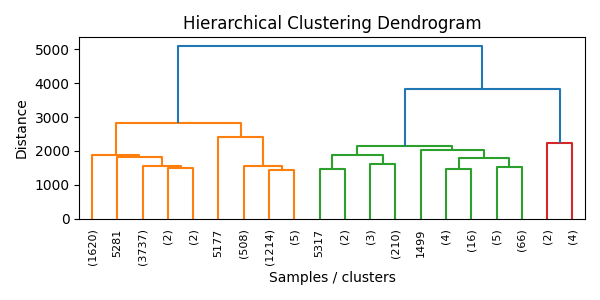

In [54]:
fig = hierarchical.plot_dendrogram(
    truncate_mode="lastp",
    p=20,
    figsize=(6, 3)
)

---
### Graph-Based Clustering

Graph-based clustering methods represent the dataset as a graph in which each node corresponds to a cell and edges connect cells with similar expression profiles.
Typically, a k-nearest-neighbor (kNN) graph is constructed from a distance matrix or a low-dimensional embedding. Cells that are close in expression space become connected, while distant cells remain disconnected or weakly connected.
Clustering is then performed directly on the graph structure by identifying densely connected communities. Popular algorithms include Leiden and Louvain clustering, which have become standard approaches in modern single-cell analysis.
Unlike K-Means, graph-based methods do not assume spherical cluster shapes and can capture complex biological structures, making them particularly suitable for heterogeneous cellular populations and developmental trajectories.


In [55]:
graph_cluster = GraphBasedClustering(
    k_neighbors=10,
    distance=CosineDistance(),
    resolution=1.0,
)

assignments = scifate_data.create_clustering(
    clustering = graph_cluster,
    entity = "trajectory",
    data = "expression",
    reduction = RandomProjektions(
        data_dim = scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],
        feature_dim = 500
    )
)

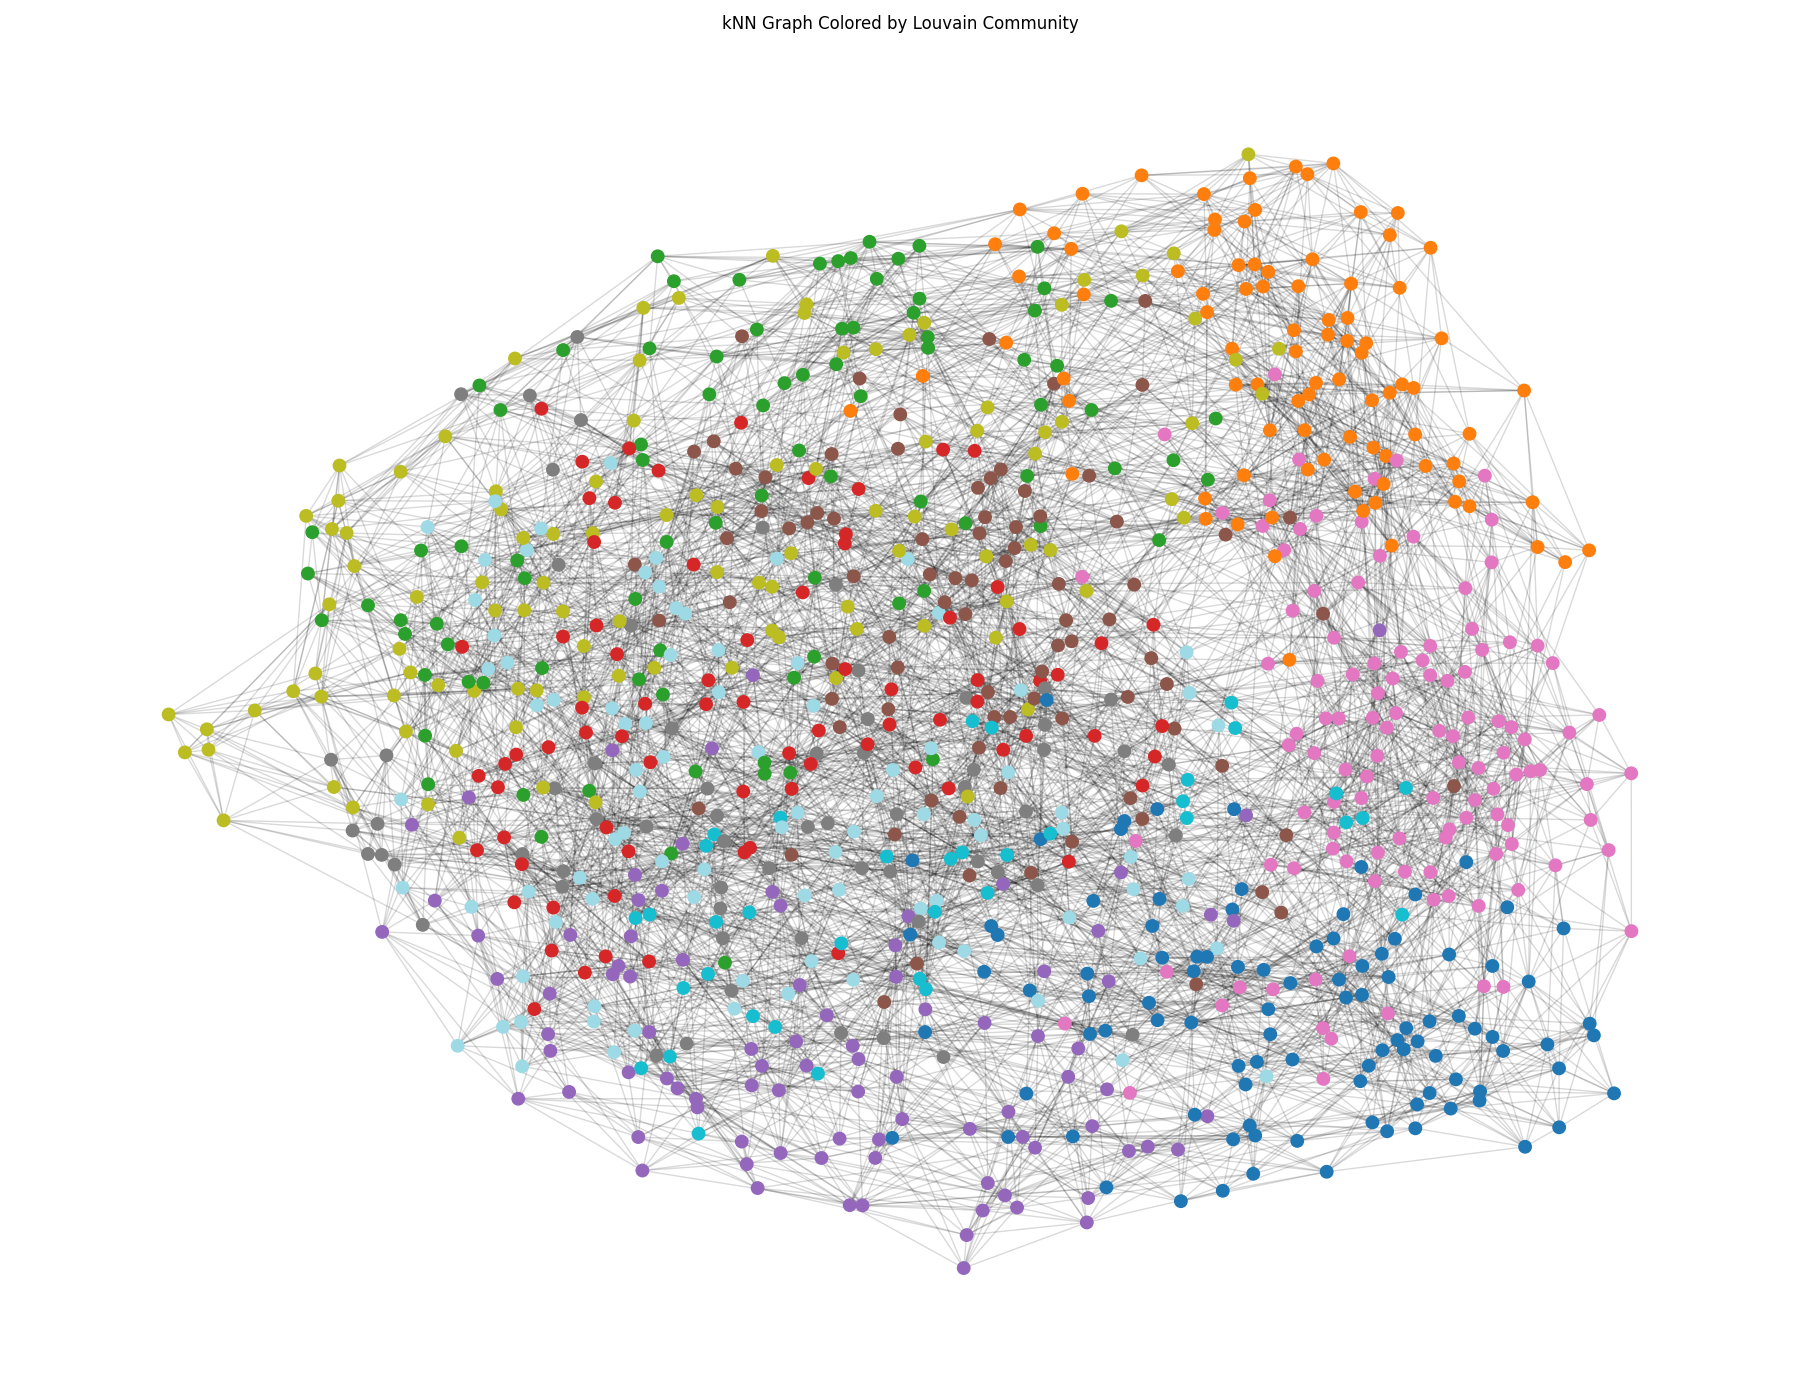

In [56]:
fig = graph_cluster.plot_graph(
    figsize=(18, 14),
    layout_k=4.0,
    iterations=1000,
    node_size=80,
    edge_alpha=0.15,
    show_node_label=False,
)

---
---
## 6.2. Visualizing Clusters

After applying a clustering algorithm, the resulting cluster assignments must be examined to determine whether they capture meaningful structure within the data. Numerical clustering metrics alone are often insufficient, as they do not reveal the biological characteristics of the identified groups. Cluster visualizations provide an important link between computational results and biological interpretation. By exploring cluster composition, cluster homogeneity, temporal dynamics, and representative cluster members, it becomes possible to assess whether the clustering reflects meaningful cellular or transcriptional patterns. Depending on the data and clustering method, different visualization strategies can be employed. These include analyses based on cluster sizes, distance matrices, metadata distributions, representative trajectories, and temporal expression patterns. Together, these visualizations provide a comprehensive view of the clustering results and help identify both biologically relevant groups and potential clustering artifacts.


---
### Number of Trajectories per Cluster

One of the first aspects to examine after clustering is the distribution of trajectories across the identified clusters. This provides a simple overview of the clustering result and helps assess whether the partitioning is balanced.
Large clusters may represent common transcriptional programs shared by many trajectories, whereas small clusters can indicate rare cellular states, specialized responses, or potential outliers. Extremely small clusters may also suggest that the selected number of clusters is too large and that the algorithm has fragmented the data into overly specific groups.
By visualizing the number of trajectories assigned to each cluster, we obtain an initial impression of the overall cluster structure before performing more detailed analyses of cluster composition, temporal behavior, and biological characteristics.

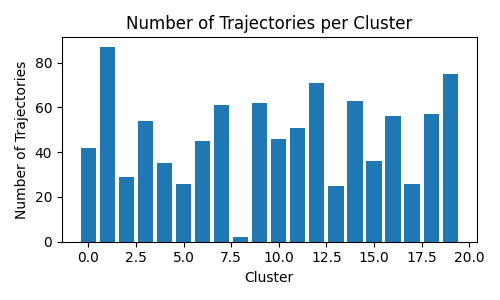

In [57]:
cluster_sizes = assignments_knn["cluster"].value_counts().sort_index()

plt.figure(figsize=(5, 3))

plt.bar(
    cluster_sizes.index,
    cluster_sizes.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Trajectories")
plt.title("Number of Trajectories per Cluster")

plt.tight_layout()
plt.show()

---
### Distribution of Values within Clusters

While cluster sizes and cluster-to-cluster distances provide information about the global structure of the clustering, it is also useful to investigate the distribution of values within each cluster.

Two complementary views can be considered:

- **Entity-based distributions**: Each cell, gene, or trajectory is represented by a single summary statistic (for example its mean, median, or total expression). The resulting distribution describes how these aggregated entities are distributed within a cluster.
- **Value-based distributions**: Instead of aggregating entities, all individual values are considered directly. This provides a more detailed view of the underlying expression landscape and allows the identification of sparsity, multimodality, skewness, or heavy-tailed behavior within clusters.

It should be noted that these distributions represent only a **one-dimensional projection** of the data. Relationships between different genes, cells, trajectories, or features are ignored, and therefore important multivariate structures cannot be observed directly. For example, two clusters may exhibit very similar expression distributions while still being clearly separable in a high-dimensional feature space. Despite this limitation, distribution plots remain highly informative. They provide an intuitive summary of cluster composition, reveal potential outliers, identify differences in variability, and help assess whether clusters represent compact and homogeneous groups or highly heterogeneous populations. As a result, they serve as a useful complement to distance-based and high-dimensional visualizations.

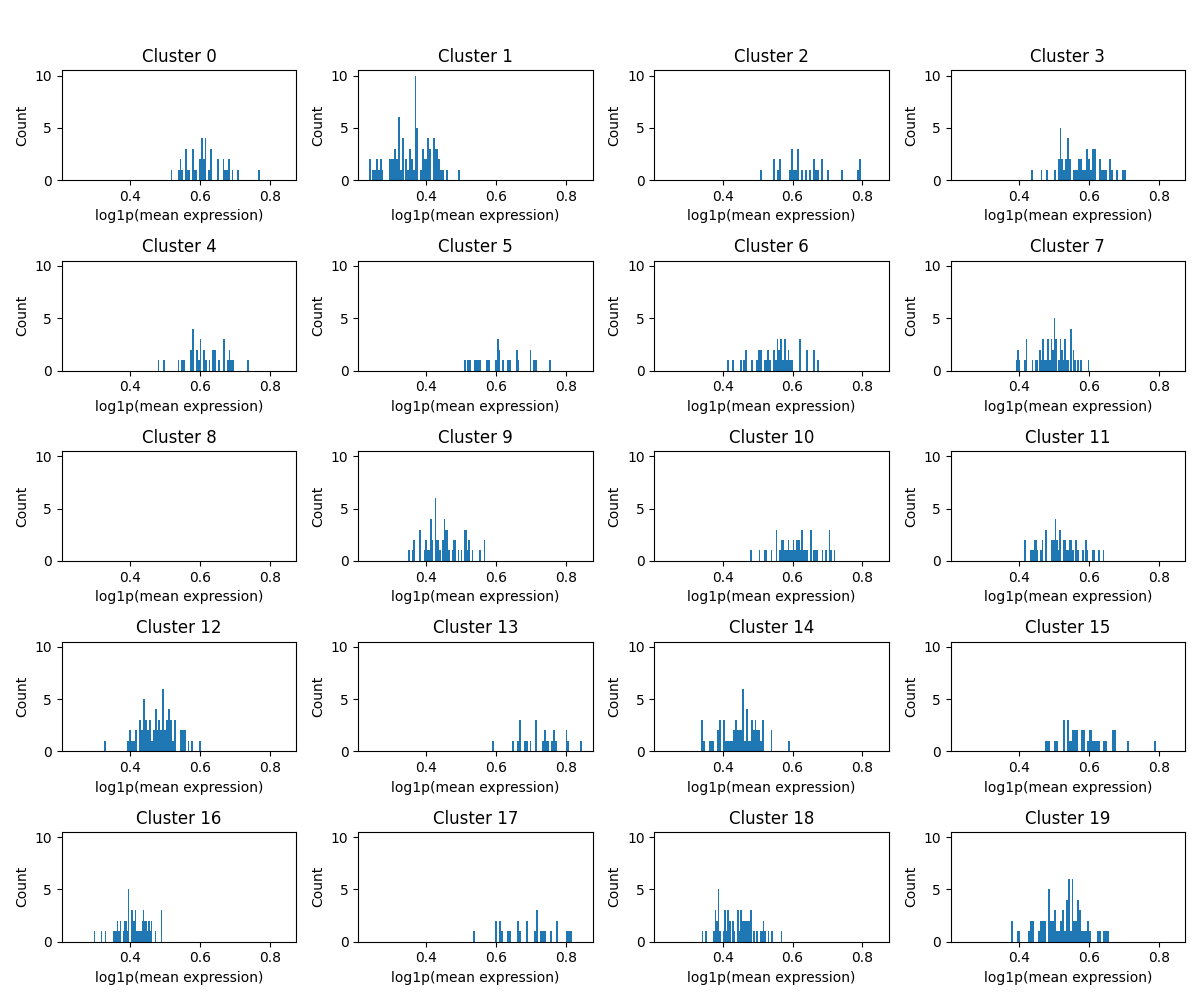

In [58]:
fig, value_df = plotter.plot_cluster_value_distribution(
    cluster_assignment = assignments_knn,
    entity = "trajectory",
    data = "expression",
    mode="entity",                                                      # this is "entity" or "vlaue"
    aggregation = "mean",                                                # this is "mean" or "sum" or "median"
    figsize_per_plot = (3,2)
)

---
### Inter- and Intra-Cluster Distances

Cluster distance matrices provide a quantitative way to assess both the separation between clusters and the compactness of individual clusters. For two clusters \(C_i\) and \(C_j\), the inter-cluster distance is computed as the mean distance between all points belonging to cluster \(C_i\) and all points belonging to cluster \(C_j\):

$$
d(C_i, C_j) =
\frac{1}{|C_i||C_j|}
\sum_{x \in C_i}
\sum_{y \in C_j}
d(x, y)
$$

When \(i=j\), the same formula describes the intra-cluster distance, which measures the average distance between samples within the same cluster. Large inter-cluster distances indicate that clusters are well separated and represent distinct regions of the data space. Small inter-cluster distances suggest that clusters are similar and may share common biological characteristics. In contrast, small intra-cluster distances indicate compact and homogeneous clusters, whereas large intra-cluster distances suggest greater variability within a cluster.

The resulting cluster distance matrix can be visualized as a heatmap:

- **Diagonal entries** represent intra-cluster distances.
- **Off-diagonal entries** represent inter-cluster distances.

A desirable clustering typically exhibits:

- **small values on the diagonal** (compact clusters),
- **large values off the diagonal** (well-separated clusters).

Such a pattern indicates that samples within a cluster are highly similar to one another while remaining distinct from samples in other clusters.

In [59]:
inter_cluster_dist = scifate_data.cluster_distance_matrix(
                                    clustering = "KMeans", 
                                    entity = "trajectory",                                              # this can be "cell" or "gene" or "trajectory"
                                    data = "expression",                                                # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                    reduction = "RandomProjection",                                     # this is to fit the notebook                                        
                                    distance = EuclideanDistance()                                      # this can be any distance class
                                )

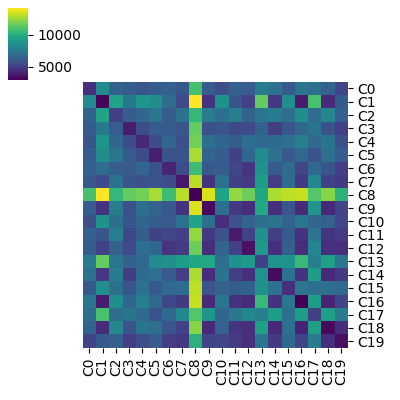

In [60]:
plotter.plot_distance_matrix(dist_matrix=inter_cluster_dist, cluster_cols=False, cluster_rows=False, figsize=(4,4));

---
### Cluster Network Visualization
The inter-cluster distance matrix can also be interpreted as a network describing the relationships between clusters. In this representation, each cluster is modeled as a node, while edges connect clusters that are similar to one another according to the selected distance measure. The resulting graph provides a complementary view to the cluster distance heatmap. Whereas the heatmap focuses on pairwise distances, the network emphasizes the overall structure and connectivity of the clustering solution. Typically, clusters that are close in the feature space are connected by stronger edges, while distant clusters are connected by weaker edges or not connected at all. This allows groups of related clusters to emerge naturally as connected regions within the graph.

Such a visualization can help answer questions such as:
- Which clusters are most similar to each other?
- Are there groups of clusters that form larger communities?
- Which clusters occupy isolated regions of the data space?
- Do some clusters appear to bridge otherwise separated groups?

It is important to note that the network representation is derived directly from the cluster distance matrix and therefore depends on the selected distance measure.

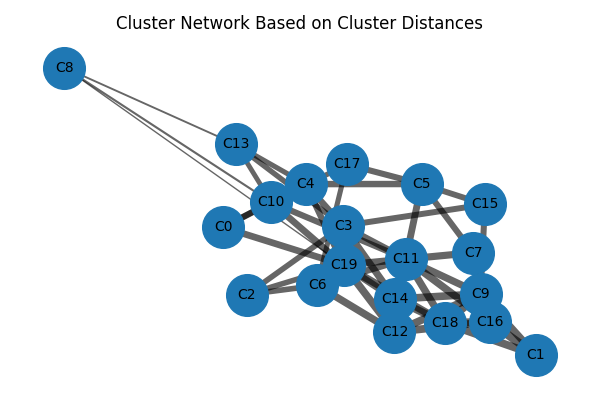

In [61]:
fig, G = plotter.plot_cluster_network(
    cluster_distance_matrix=inter_cluster_dist,
    k_neighbors=3,
    figsize=(6,4),
    show_edge_labels=False
)

---
### Mean/Medoid Trajectory over Time

While cluster distance matrices provide information about the separation between clusters, they do not directly reveal the biological dynamics represented by each cluster of trajectorys. To better understand the temporal behavior of the clustered trajectories, we can compute a representative trajectory for every cluster and visualize its development over time.

Several aggregation strategies can be used:

- **Mean**: The average value across all trajectories belonging to a cluster at each time point.
- **Median**: The median value across all trajectories at each time point, providing a more robust estimate that is less sensitive to outliers.
- **Sum**: The total signal across all trajectories within a cluster at each time point.
- **Medoid**: Instead of constructing an artificial average trajectory, the medoid selects the most representative real trajectory within the cluster. The medoid is defined as the trajectory with the smallest average distance to all other trajectories in the same cluster.

The mean, median, and sum aggregations generate synthetic cluster representatives by combining information from multiple trajectories. These summaries provide a smooth overview of the overall cluster behavior and are useful for identifying common temporal trends. In contrast, the medoid corresponds to an actual observed trajectory. This often leads to a more realistic representation of the cluster, especially when trajectories exhibit strong heterogeneity or when averaging would smooth out important biological patterns.

By plotting these representative trajectories over time, it becomes possible to identify characteristic cluster behaviors such as:

- increasing expression over time,
- decreasing expression over time,
- transient activation or repression,
- stable expression profiles,
- delayed responses compared to other clusters.

These trajectory summaries provide an intuitive biological interpretation of the clustering results and help relate cluster structure to temporal cellular dynamics.

In [62]:
fig, info_df = plotter.plot_cluster_trajectories_over_time(
                                                                # entity = "trajectory",                                # this is automaticaly set 
                                                                data = "expression",                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                                clustering = "KMeans",
                                                                reduction  = "RandomProjection",
                                                                distance = EuclideanDistance(),
                                                                genes = None,                                           # we will get the aggregation of all genes 
                                                                aggregation = "mean",                                   # this can be "mean" or "sum" or "median" or "medoid"
                                                                figsize=(10, 6)
                                                            )
fig.show()

In [63]:
fig, info_df = plotter.plot_cluster_trajectories_over_time(
                                                                # entity = "trajectory",                                # this is automaticaly set 
                                                                data = "expression",                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                                clustering = "KMeans",
                                                                reduction  = "RandomProjection",
                                                                distance = EuclideanDistance(),
                                                                genes = None,                                           # we will get the aggregation of all genes 
                                                                aggregation = "medoid",                                 # this can be "mean" or "sum" or "median" or "medoid"
                                                                figsize=(10, 6)
                                                            )
fig.show()

---
### Conclusion
The visualizations presented throughout this analysis provide valuable insights into the structure and characteristics of the dataset. Distance scores, highly variable genes, cluster sizes, cluster distance matrices, value distributions, and representative trajectories all highlight different aspects of the underlying biological system and help transform high-dimensional data into interpretable summaries.
However, it is important to recognize that nearly all of these visualizations rely on some form of aggregation or projection of the original data. As a result, they provide only a limited view of the underlying high-dimensional structure. Complex relationships between genes, cells, and trajectories are often reduced to a small number of summary statistics, distributions, or pairwise comparisons.
While these visualizations are extremely useful for gaining intuition and understanding the data, they cannot fully capture the structure of the original feature space. Important patterns may therefore remain hidden when the data is viewed only through one-dimensional summaries.
A natural next step is to apply **dimensionality reduction techniques**, which aim to preserve as much of the original structure as possible while projecting the data into a low-dimensional representation that can be visualized directly. Such approaches make it possible to explore global and local relationships between samples while retaining substantially more information than simple aggregated statistics.
For this reason, the next section focuses on dimensionality reduction methods and their application to the SciFate dataset.
The corresponding analyses are presented in Section <span style="color:orange">7. Dimension Reduction and Plotting Data</span>.

---
---
## 7. Dimension Reduction and Plotting Data

The original expression matrix consists of thousands of genes and therefore resides in a very high-dimensional space. While clustering can be performed directly on this data, understanding and interpreting the resulting structure is often challenging. Dimensionality reduction methods project the data into a lower-dimensional space while attempting to preserve important properties of the original dataset.
Different dimensionality reduction techniques focus on preserving different aspects of the data. PCA aims to preserve variance, random projections approximately preserve pairwise distances, and autoencoders learn nonlinear representations directly from the data. Consequently, the same dataset may appear differently depending on the chosen reduction method.

The following dimensionality reduction methods are considered in this notebook:

| Method | Linear | Nonlinear | Preserves Variance | Preserves Distances | Requires Training | Supports Sparse Data |
|----------|----------|----------|----------|----------|----------|----------|
| PCA | Yes | No | Yes | No | No | Partially |
| Random Projection | Yes | No | No | Yes (approximately) | No | Yes |
| Autoencoder | No | Yes | Learned | Learned | Yes | Yes |

PCA identifies directions of maximal variance and serves as a strong and interpretable baseline. Random projections are computationally efficient and are primarily designed to approximately preserve pairwise distances, making them useful for large-scale distance calculations. Autoencoders are the most flexible approach and can learn complex nonlinear representations directly from the data, but require model training and additional hyperparameter tuning.

For each dimensionality reduction technique, the resulting low-dimensional embedding is visualized and colored according to the previously computed cluster assignments. These visualizations provide a qualitative assessment of the clustering results and help determine whether clusters form compact groups, overlap with one another, or reveal additional structure that may not be obvious from numerical evaluation alone.

It is important to note that every visualization shown in this section is a projection of a much higher-dimensional dataset. Therefore, some information is inevitably lost during dimensionality reduction, and relationships observed in the visualization may not fully represent the structure of the original data.

In [64]:
from sciflow.reduction import Autoencoder, PCA

---
### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a classical dimensionality reduction technique that projects high-dimensional data onto a smaller set of orthogonal components while preserving as much variance as possible. The resulting principal components are ordered according to the amount of variance they explain. For large and sparse single-cell datasets, computing a full PCA can be computationally expensive. Therefore, this implementation uses **Truncated Singular Value Decomposition (TruncatedSVD)**, which efficiently computes only the most important components and can operate directly on sparse matrices.

Two parameters are distinguished:

* **calculated_components**: number of components computed internally.
* **n_components**: number of components returned in the reduced representation.

This allows the explained variance to be analyzed using many components while still generating a compact embedding for visualization and clustering.
The cumulative explained variance can be used to determine how many principal components are required to retain most of the information contained in the original dataset.

In [65]:
pca = PCA(n_components = 3, calculated_components = 100)

pca_matrix = scifate_data.create_reduced_matrix(
    reduction=pca,
    entity="trajectory",
    data="expression",
    save=True,
)

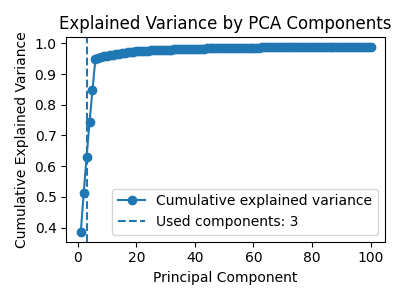

In [66]:
fig = pca.plot_explained_variance(
    figsize=(4,3)
)

After dimensionality reduction, each cell is represented by three principal components and can therefore be visualized in a three-dimensional space. To evaluate the clustering results, cells are colored according to their graph-based kNN cluster assignments. Cells with similar expression profiles are expected to appear close together in the embedding, while distinct cell populations should form separate groups. Although PCA only provides a linear projection of the original data, it offers a useful overview of the global structure of the dataset and allows the clustering results to be inspected visually.

In [67]:
plotter.plot_reduced_matrix(
    pca_matrix,
    dimensions = (0,1,2),
    color_by = assignments_knn["cluster"]                        
)

---
### Autoencoder

While methods such as PCA and Random Projection perform dimensionality reduction using predefined linear transformations, autoencoders learn a task-specific low-dimensional representation directly from the data.

An autoencoder consists of two neural networks:
- an **encoder**, which compresses the input data into a low-dimensional latent representation,
- a **decoder**, which reconstructs the original data from this latent representation.

During training, the model minimizes the reconstruction error between the original input and the reconstructed output. As a consequence, the encoder learns a compressed representation that preserves the most important information required to reconstruct the data. For this analysis, a deep autoencoder was trained on the cell expression matrix. The encoder gradually reduces the dimensionality from the original gene expression space to a latent representation consisting of only three dimensions:

```text
Input => 1024 => 256 => 128 => 16 => 3 => 16 => 128 => 256 => 1024 => Output
```

Several techniques were incorporated to improve the quality and robustness of the learned representation:

- **GELU activations** introduce nonlinearities that allow the model to capture complex biological relationships.
- **Batch normalization** stabilizes training and accelerates convergence.
- **Dropout** reduces overfitting by randomly deactivating neurons during training.
- **Attention layers** in the deeper parts of the encoder allow the model to focus on particularly informative latent features.
- **Sparsity regularization** encourages compact representations and is especially suitable for sparse single-cell expression data.

Unlike PCA, which is restricted to linear transformations, the autoencoder can learn highly nonlinear structures. This makes it possible to capture complex relationships between genes and cells that may not be visible in linear embeddings.
After training, only the encoder part of the network is used. Each cell is mapped into the three-dimensional latent space.

In [68]:
autoencoder = Autoencoder(
    input_dim=scifate_data.expression_matrix.n_cols,
    layer_dims=[1024, 256, 128, 16, 3],
    attention_on_layers=[False, False, False, True, True],
    activation="gelu",
    dropout=0.1,
    batch_norm=True,
    learning_rate=1e-3,
    batch_size=256,
    sparsity_loss=True,
    sparsity_weight=1e-4,
    epochs=65
)

In [69]:
autoencoder.load("../models/autoencoder_cell_expression.pt");
autoencoder.is_fitted = True

reduced_matrix = scifate_data.create_reduced_matrix(
    reduction= autoencoder,
    entity = "cell",
    data = "expression",
    save = True,
    save_model = True
)

# autoencoder.save("../models/autoencoder_cell_expression.pt");

In [70]:
plotter = ScifatePlotter(scifate_data)

We can plot the reduced matrix in respect to the diverent trajectorys 

In [71]:
plotter.plot_reduced_matrix(
    reduced_matrix,
    dimensions=(0, 1, 2),
    color_by = "trajectory",
    entity = "cell"
)

We can plot the reduced matrix where we use the Cluster of the cluster assigments of hirachical clustering

In [72]:
plotter.plot_reduced_matrix(
    reduced_matrix,
    dimensions = (0,1,2),
    color_by = assignments_hic["cluster"]                        
)

--- 
### Random Projection
Unlike PCA or autoencoders, the primary purpose of random projections is not to create a low-dimensional embedding for visualization. Instead, random projections are mainly used to reduce computational complexity while approximately preserving pairwise distances between data points. This makes them particularly useful for large-scale distance calculations and clustering tasks. Nevertheless, the projected data can also be visualized in two or three dimensions. Although such low-dimensional projections preserve the original geometry less accurately than projections with higher target dimensions, they can still provide a useful qualitative impression of the global structure of the dataset. The following plots therefore serve mainly as an exploratory visualization rather than the primary application of random projections.

In [73]:
randproj = RandomProjektions(
                        data_dim = scifate_data.expression_matrix.n_cols,
                        feature_dim = 3
                    )

reduced_matrix_rp = scifate_data.create_reduced_matrix(
    reduction= randproj,
    entity = "cell",
    data = "expression",
    save = True
)

In [74]:
plotter.plot_reduced_matrix(
    reduced_matrix_rp,
    dimensions=(0,1,2),
    color_by= assignments_hic["cluster"]                        
)